# Bivariate analysis

### Setup libraries and pandas view:

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

C:\Users\Tom\AppData\Local\Temp\ipykernel_1344\361401215.py:6: DtypeWarning: Columns (0: Assay Subcellular Fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')


### Filtering data based on previous audit:

In [9]:
conclusive_rows = df[(df['Standard Type'] == 'Potency') 
                     & (df['Standard Value'] != 28183.8) 
                     & (df['Comment'] != 'inconclusive')
                     & (df['Assay ChEMBL ID'] == 'CHEMBL2114788')].dropna(axis=1, how='all')

print(conclusive_rows.shape)

(21412, 28)


### Correlation matrices and correlation heatmaps:

Pearson
                     Molecule Max Phase  Molecular Weight  #RO5 Violations     AlogP  Standard Value  Potential Duplicate  Source ID     Value
Molecule Max Phase             1.000000          0.097125         0.007819 -0.008343        0.151234                  NaN        NaN  0.151234
Molecular Weight               0.097125          1.000000         0.494750  0.410730       -0.040166                  NaN        NaN -0.040166
#RO5 Violations                0.007819          0.494750         1.000000  0.492518       -0.042123                  NaN        NaN -0.042123
AlogP                         -0.008343          0.410730         0.492518  1.000000       -0.115872                  NaN        NaN -0.115872
Standard Value                 0.151234         -0.040166        -0.042123 -0.115872        1.000000                  NaN        NaN  1.000000
Potential Duplicate                 NaN               NaN              NaN       NaN             NaN                  NaN        NaN  

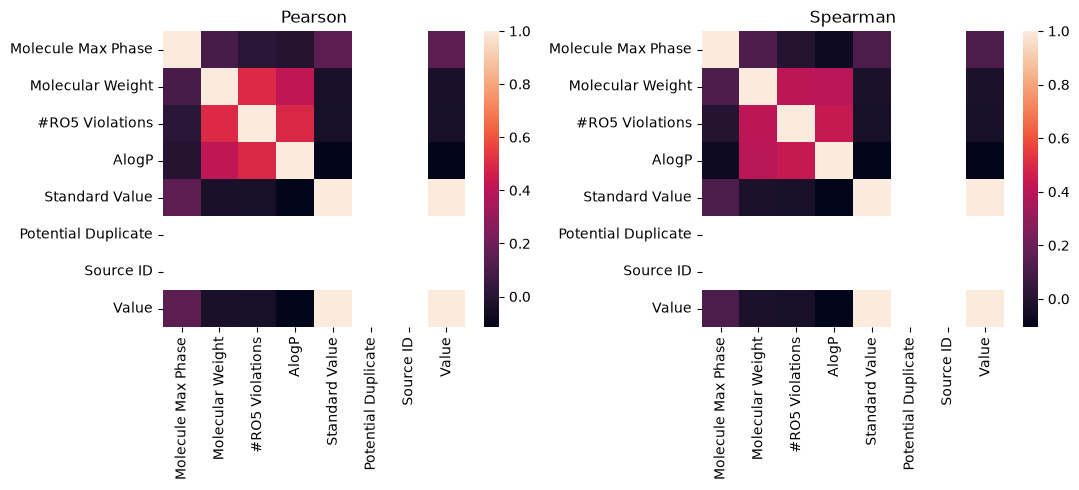

In [10]:
corr_matrix = conclusive_rows.corr(numeric_only=True, method='pearson')
corr_matrix_spear = conclusive_rows.corr(numeric_only=True, method='spearman')
print(f"Pearson")
print(corr_matrix, '\n')
print(f"Spearman")
print(corr_matrix_spear, '\n')

fig, axes = plt.subplots(1, 2, figsize=(11,5))
sns.heatmap(corr_matrix, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_matrix_spear, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Difference between Pearson and Spearman')

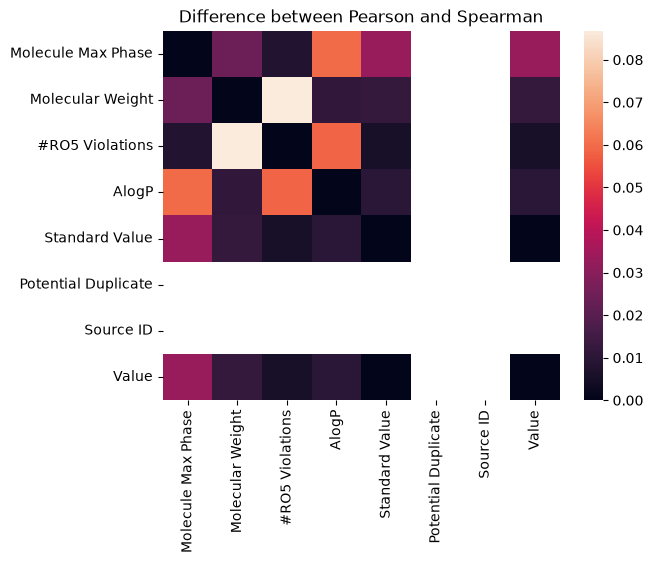

In [11]:
corr_diff = abs(corr_matrix - corr_matrix_spear)
sns.heatmap(corr_diff).set_title('Difference between Pearson and Spearman')

### Plots of most correlated fields:

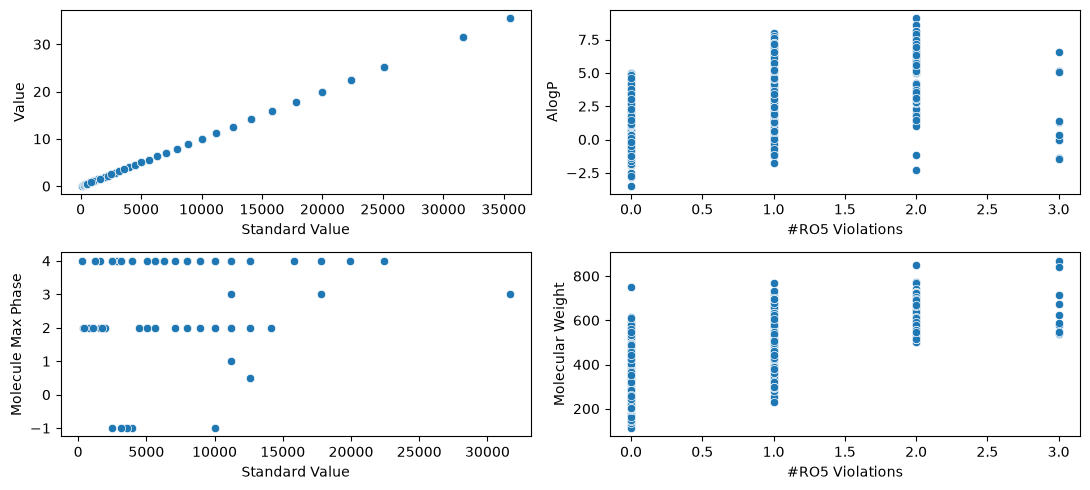

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11,5))
sns.scatterplot(x=conclusive_rows['Standard Value'], y=conclusive_rows['Value'], ax=axes[0,0])
sns.scatterplot(x=conclusive_rows['Standard Value'], y=conclusive_rows['Molecule Max Phase'], ax=axes[1,0])
sns.scatterplot(x=conclusive_rows['#RO5 Violations'], y=conclusive_rows['AlogP'], ax=axes[0,1])
sns.scatterplot(x=conclusive_rows['#RO5 Violations'], y=conclusive_rows['Molecular Weight'], ax=axes[1,1])
plt.tight_layout()

### Violin plot of Standard Value vs Comment:

<Axes: xlabel='Comment', ylabel='Standard Value'>

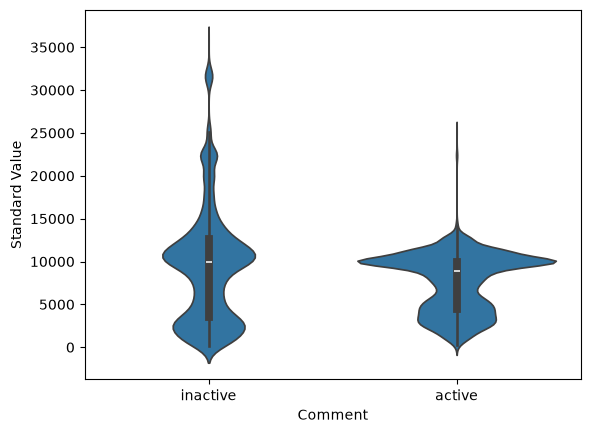

In [13]:
sns.violinplot(y=conclusive_rows['Standard Value'], x=conclusive_rows['Comment'])


### Violin plot of Standard Value vs #ROS violations:

#RO5 Violations
0.0    18886
1.0     2138
2.0      360
3.0       11
Name: count, dtype: int64


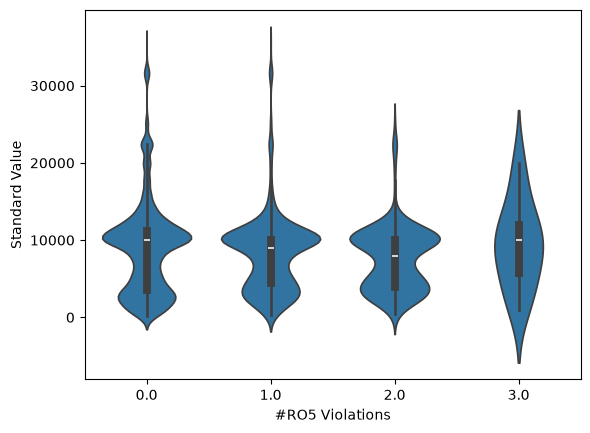

In [14]:
sns.violinplot(y=conclusive_rows['Standard Value'], x=conclusive_rows['#RO5 Violations'])

print(conclusive_rows['#RO5 Violations'].value_counts())